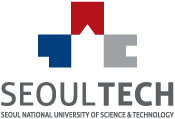

# Final examination - Predictive Maintenance in Automotive Robotics
---

by Prof. Josué Obregón <br>
Data Analysis for Electronic Manufacturing <br>
Department of Data Science - SeoulTech<br>



# Instructions

You are a data scientist in an automotive factory.
You receive data from an industrial robot manipulator that loads raw parts into a CNC machine and removes them after machining (Fig 1).

# 시험 지시사항

귀하는 자동차 제조 공장에서 근무하는 데이터 사이언티스트입니다.
귀하는 원자재 부품을 CNC 기계에 적재하고, 가공 완료 후 이를 제거하는 산업용 로봇 매니퓰레이터로부터 수집된 데이터를 제공받았습니다(그림 1 참조).



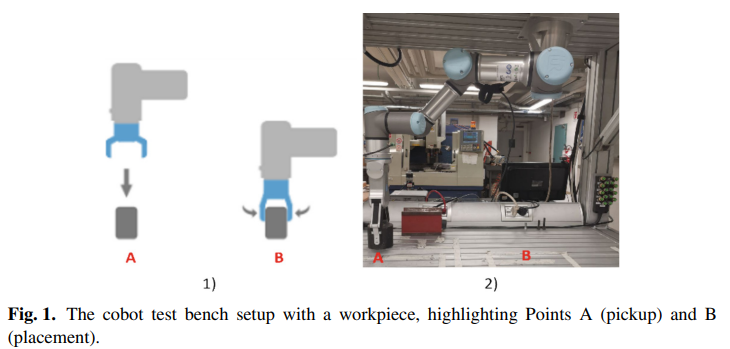

The variables collected are described in Table 1.

Note: The variable **Cycle** was discarded in this dataset

수집된 변수들은 표 1에 상세히 제시되어 있습니다.

참고: **Cycle** 변수는 본 데이터셋에서 제외되었습니다.


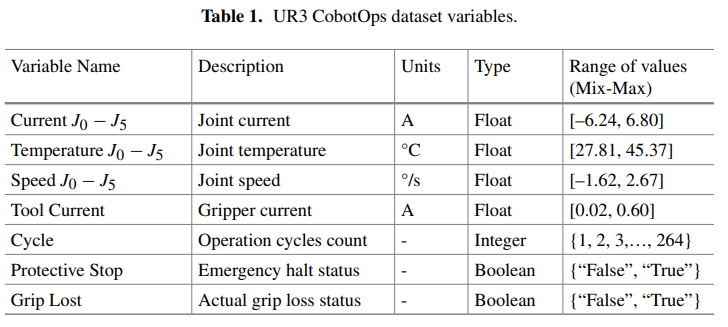

In [82]:
#Run this cell to download the dataset  # 본 데이터셋을 다운로드하기 위해 아래 셀을 실행하십시오
!gdown 1EqVGgSWshANXIvHdnLHVJajyyZrLRqBn

Downloading...
From: https://drive.google.com/uc?id=1EqVGgSWshANXIvHdnLHVJajyyZrLRqBn
To: /content/dataset_cobots.csv
100% 2.01M/2.01M [00:00<00:00, 119MB/s]


Your task is to develop a fault prediction model using the provided dataset.

After loading the CSV file into a pandas DataFrame, complete the following tasks.

*Note: You can freely add new text and code cells for implementing every task.*

제공된 데이터셋을 활용하여 고장(fault) 예측 모델을 개발하는 것이 여러분의 과제입니다.

CSV 파일을 pandas DataFrame으로 불러온 후, 아래에 제시된 각 과제를 순서대로 수행하십시오.

참고: 각 과제를 구현하기 위해 필요한 경우 텍스트 셀과 코드 셀을 자유롭게 추가하여 사용해도 됩니다.


In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, PowerTransformer, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score

from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.model_selection import KFold

In [84]:
df = pd.read_csv("/content/dataset_cobots.csv")

In [85]:
df

,Current_J0,Temperature_T0,Current_J1,Temperature_J1,Current_J2,Temperature_J2,Current_J3,Temperature_J3,Current_J4,Temperature_J4,...,Temperature_J5,Speed_J0,Speed_J1,Speed_J2,Speed_J3,Speed_J4,Speed_J5,Tool_current,Robot_ProtectiveStop,grip_lost
0,0.109628,27.8750,-2.024669,29.3750,-1.531442,29.3750,-0.998570,32.1250,-0.062540,32.2500,...,32.0000,2.955651e-01,-0.000490,0.001310,-0.132836,-0.007479,-0.152962,0.082732,False,False
1,0.595605,27.8750,-2.278456,29.3125,-0.866556,29.4375,-0.206097,32.1875,-1.062762,32.2500,...,32.0000,-7.391485e-30,-0.000304,0.002185,0.001668,-0.000767,0.000417,0.505895,False,False
2,-0.229474,27.8750,-2.800408,29.3125,-2.304336,29.4375,-0.351499,32.1250,-0.668869,32.3125,...,32.0625,1.369386e-01,0.007795,-2.535874,0.379867,0.000455,-0.496856,0.079420,False,False
3,0.065053,27.8750,-3.687768,29.3125,-1.217652,29.4375,-1.209115,32.1250,-0.819755,32.2500,...,32.0000,-9.030032e-02,-0.004911,-0.009096,-0.384196,0.018411,0.425559,0.083325,False,False
4,0.884140,27.8750,-2.938830,29.3750,-1.794076,29.4375,-2.356471,32.1875,-0.966427,32.3125,...,32.0000,1.268088e-01,0.005567,0.001138,-0.353284,0.014994,0.180989,0.086379,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7404,-0.109017,37.1875,-2.261695,40.3125,-1.082678,40.6875,-0.494714,43.3750,-0.019447,45.2500,...,44.5625,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.080013,False,False
7405,-0.098536,37.1875,-2.251992,40.3125,-1.094420,40.6875,-0.515789,43.3750,-0.009186,45.2500,...,44.5000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.078740,False,False
7406,-0.121100,37.1875,-2.280791,40.2500,-1.121319,40.6875,-0.502406,43.3750,-0.002978,45.2500,...,44.5000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.091471,False,False
7407,-0.129370,37.1875,-2.269061,40.3125,-1.091610,40.6250,-0.491158,43.3750,-0.001136,45.2500,...,44.5625,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.090026,False,False


## 1. Missing Data (5 points)

- Detect and handle missing data properly.
  - Choose an appropriate strategy and briefly justify your decision.


*Note: For this exam, do not analyze or handle outliers.*

## 1. 결측치 처리 (5점)

- 결측치를 탐지하고 적절한 방식으로 처리하십시오.
  - 선택한 처리 방법에 대해 간단히 정당성을 제시하십시오.

*참고: 본 시험에서는 이상치(outlier)를 분석하거나 처리하지 않습니다.*


In [86]:
df.isnull().sum()

,0
Current_J0,46
Temperature_T0,54
Current_J1,54
Temperature_J1,54
Current_J2,54
Temperature_J2,54
Current_J3,54
Temperature_J3,54
Current_J4,54
Temperature_J4,54


# **I will fill missing values with mediean because if fill by mean, it will effect value of mean in case there're outliers. and the dataset is not big so I will not remove missing values.**

In [87]:
df_fill_missing_values = df.copy()

In [88]:
columns = df.select_dtypes(include="number").columns

In [89]:
columns

Index(['Current_J0', 'Temperature_T0', 'Current_J1', 'Temperature_J1',
       'Current_J2', 'Temperature_J2', 'Current_J3', 'Temperature_J3',
       'Current_J4', 'Temperature_J4', 'Current_J5', 'Temperature_J5',
       'Speed_J0', 'Speed_J1', 'Speed_J2', 'Speed_J3', 'Speed_J4', 'Speed_J5',
       'Tool_current'],
      dtype='object')

In [90]:
for column in columns:
    df_fill_missing_values[column] = df_fill_missing_values[column].fillna(df_fill_missing_values[column].mean())

In [91]:
df_fill_missing_values.isnull().sum()

,0
Current_J0,0
Temperature_T0,0
Current_J1,0
Temperature_J1,0
Current_J2,0
Temperature_J2,0
Current_J3,0
Temperature_J3,0
Current_J4,0
Temperature_J4,0


## 2. Create the Target Variable (10 points)

You are informed that *Robot_ProtectiveStop* and *grip_lost* both indicate a robot failure. Which means that when at least one of both variables is true, we can assume there is a robot failure.

- Create a new variable *failure* in your dataframe that represents a robot failure.
- Visualize your new target variable using a proper plot.
- Provide 1–2 sentences commenting on your findings.

## 2. 타깃 변수 생성 (10점)

*Robot_ProtectiveStop* 변수와 *grip_lost* 변수는 모두 로봇의 고장 여부를 나타내는 지표입니다.  
두 변수 중 하나라도 참(True)인 경우, 로봇에 고장이 발생한 것으로 간주할 수 있습니다.

- 데이터프레임에 로봇 고장을 나타내는 새로운 변수 *failure*를 생성하십시오.
- 생성한 타깃 변수를 적절한 시각화 기법을 사용하여 그래프로 표현하십시오.
- 시각화 결과에 대해 1–2문장으로 간단한 의견을 제시하십시오.


In [92]:
df_fill_missing_values

,Current_J0,Temperature_T0,Current_J1,Temperature_J1,Current_J2,Temperature_J2,Current_J3,Temperature_J3,Current_J4,Temperature_J4,...,Temperature_J5,Speed_J0,Speed_J1,Speed_J2,Speed_J3,Speed_J4,Speed_J5,Tool_current,Robot_ProtectiveStop,grip_lost
0,0.109628,27.8750,-2.024669,29.3750,-1.531442,29.3750,-0.998570,32.1250,-0.062540,32.2500,...,32.0000,2.955651e-01,-0.000490,0.001310,-0.132836,-0.007479,-0.152962,0.082732,False,False
1,0.595605,27.8750,-2.278456,29.3125,-0.866556,29.4375,-0.206097,32.1875,-1.062762,32.2500,...,32.0000,-7.391485e-30,-0.000304,0.002185,0.001668,-0.000767,0.000417,0.505895,False,False
2,-0.229474,27.8750,-2.800408,29.3125,-2.304336,29.4375,-0.351499,32.1250,-0.668869,32.3125,...,32.0625,1.369386e-01,0.007795,-2.535874,0.379867,0.000455,-0.496856,0.079420,False,False
3,0.065053,27.8750,-3.687768,29.3125,-1.217652,29.4375,-1.209115,32.1250,-0.819755,32.2500,...,32.0000,-9.030032e-02,-0.004911,-0.009096,-0.384196,0.018411,0.425559,0.083325,False,False
4,0.884140,27.8750,-2.938830,29.3750,-1.794076,29.4375,-2.356471,32.1875,-0.966427,32.3125,...,32.0000,1.268088e-01,0.005567,0.001138,-0.353284,0.014994,0.180989,0.086379,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7404,-0.109017,37.1875,-2.261695,40.3125,-1.082678,40.6875,-0.494714,43.3750,-0.019447,45.2500,...,44.5625,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.080013,False,False
7405,-0.098536,37.1875,-2.251992,40.3125,-1.094420,40.6875,-0.515789,43.3750,-0.009186,45.2500,...,44.5000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.078740,False,False
7406,-0.121100,37.1875,-2.280791,40.2500,-1.121319,40.6875,-0.502406,43.3750,-0.002978,45.2500,...,44.5000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.091471,False,False
7407,-0.129370,37.1875,-2.269061,40.3125,-1.091610,40.6250,-0.491158,43.3750,-0.001136,45.2500,...,44.5625,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.090026,False,False


<Axes: xlabel='Robot_ProtectiveStop', ylabel='count'>

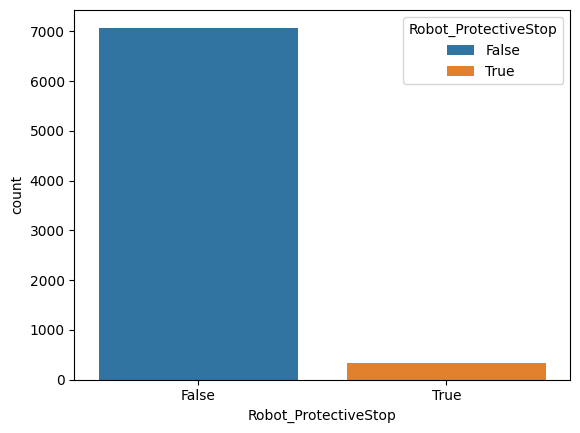

In [93]:
sns.countplot(df, x="Robot_ProtectiveStop" , hue="Robot_ProtectiveStop")

<Axes: xlabel='grip_lost', ylabel='count'>

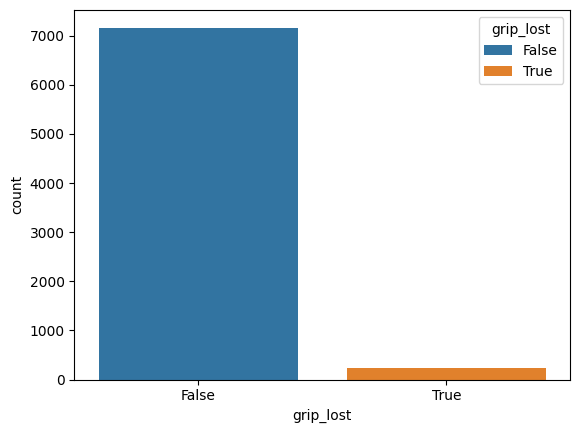

In [94]:
sns.countplot(df, x="grip_lost" , hue="grip_lost")

In [95]:
df_fill_missing_values = df_fill_missing_values.copy()


In [96]:
Robot_ProtectiveStop = df['Robot_ProtectiveStop'].values
grip_lost = df['grip_lost'].values

In [ ]:
failure = []
for i in Robot_ProtectiveStop:
    k = 0
    if i == True:
        failure.append(True)
    else:
         if grip_lost[k] == True:
            failure.append(True)
         else:
            failure.append(False)

    k = k + 1

In [98]:
df_fill_missing_values['failure'] =  failure

<Axes: xlabel='failure', ylabel='count'>

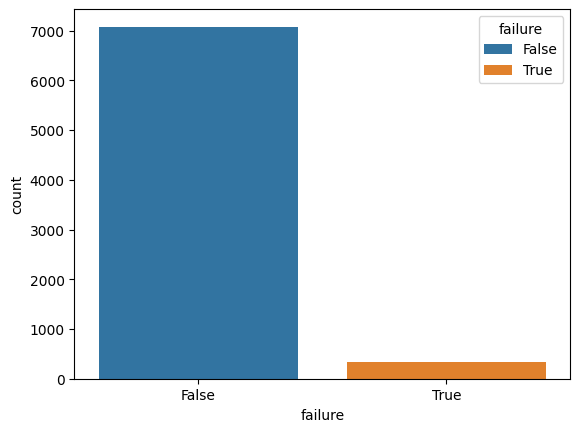

In [118]:
sns.countplot(df_fill_missing_values, x="failure" , hue="failure")

## 3. Correlation Analysis (10 points)

Compute the correlation matrix and visualize it appropriately.

- Using a threshold of |corr| > 0.6, and identify highly correlated variable pairs
(ignore Robot_ProtectiveStop and grip_lost).
- Choose two highly correlated variable pairs and draw appropriate visualizations to analyze their relationship.
- Provide 1–2 sentences interpreting your findings.

## 3. 상관분석 (10점)

상관관계 행렬(correlation matrix)을 계산하고 적절한 방식으로 시각화하십시오.

- |corr| > 0.6 기준을 사용하여 높은 상관관계를 보이는 변수 쌍을 식별하십시오  
  (단, Robot_ProtectiveStop 및 grip_lost 변수는 제외하십시오).
- 식별한 변수들 중 두 쌍을 선택하여, 변수 간 관계를 분석할 수 있는 적절한 시각화를 수행하십시오.
- 시각화 결과에 대해 1–2문장으로 간단한 해석을 제시하십시오.


<Axes: >

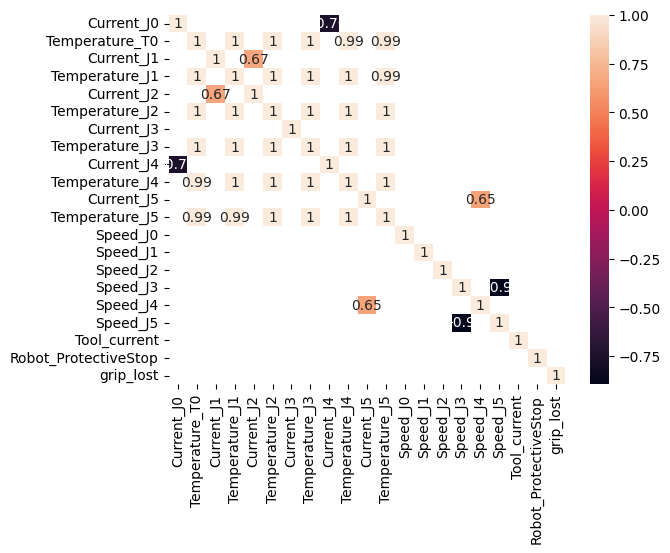

In [100]:
corr_mat = df.corr()
imp_mask = np.abs(corr_mat)>0.6
sns.heatmap(corr_mat[imp_mask], annot = True)

In [101]:
df.columns

Index(['Current_J0', 'Temperature_T0', 'Current_J1', 'Temperature_J1',
       'Current_J2', 'Temperature_J2', 'Current_J3', 'Temperature_J3',
       'Current_J4', 'Temperature_J4', 'Current_J5', 'Temperature_J5',
       'Speed_J0', 'Speed_J1', 'Speed_J2', 'Speed_J3', 'Speed_J4', 'Speed_J5',
       'Tool_current', 'Robot_ProtectiveStop', 'grip_lost'],
      dtype='object')

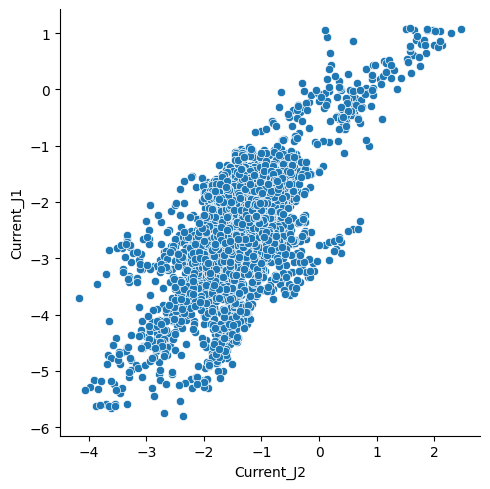

In [102]:
sns.relplot(data=df, x="Current_J2", y="Current_J1")

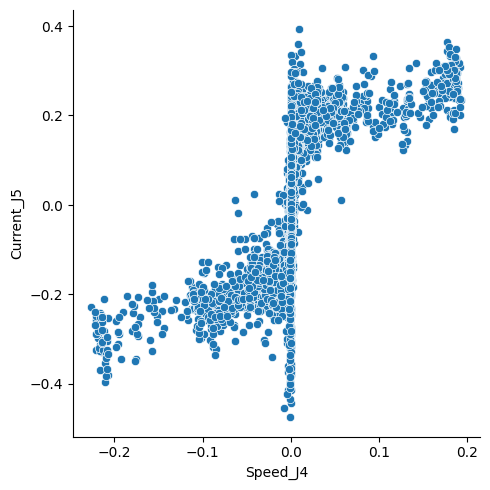

In [103]:
sns.relplot(data=df, x="Speed_J4", y="Current_J5")

## 4. Baseline Models — Single Validation Split (20 points)

Train three baseline models: Logistic Regression, KNN, and Decision Trees.

- 4.1 Define $X$ and $y$ properly. Use all predictor variables and the failure target variable.
- 4.2 Use a single train/validation split with proper proportions.
- 4.3 Choose the most appropriate performance metric for this problem and justify your choice.
- 4.4 Train and evaluate the three models using the chosen metric.
- 4.5 Create a proper visualization comparing their performance.
- 4.6 Provide comments on your results.

## 4. 기본 모델 구축 — 단일 검증 분할 (20점)

다음 세 가지 기본 모델을 학습하십시오: Logistic Regression, KNN, Decision Tree.

- 4.1 모든 예측 변수를 사용하여 $X$를 구성하고, failure 변수를 사용하여 $y$를 정의하십시오.
- 4.2 적절한 비율을 사용하여 단일 train/validation 분할을 수행하십시오.
- 4.3 본 문제에 가장 적합한 성능 평가 지표를 선택하고, 그 이유를 명확히 제시하십시오.
- 4.4 선택한 성능 지표를 사용하여 세 모델을 학습하고 평가하십시오.
- 4.5 세 모델의 성능을 비교할 수 있는 적절한 시각화를 작성하십시오.
- 4.6 모델 성능 결과에 대한 의견을 간단히 서술하십시오.


In [104]:
df

,Current_J0,Temperature_T0,Current_J1,Temperature_J1,Current_J2,Temperature_J2,Current_J3,Temperature_J3,Current_J4,Temperature_J4,...,Temperature_J5,Speed_J0,Speed_J1,Speed_J2,Speed_J3,Speed_J4,Speed_J5,Tool_current,Robot_ProtectiveStop,grip_lost
0,0.109628,27.8750,-2.024669,29.3750,-1.531442,29.3750,-0.998570,32.1250,-0.062540,32.2500,...,32.0000,2.955651e-01,-0.000490,0.001310,-0.132836,-0.007479,-0.152962,0.082732,False,False
1,0.595605,27.8750,-2.278456,29.3125,-0.866556,29.4375,-0.206097,32.1875,-1.062762,32.2500,...,32.0000,-7.391485e-30,-0.000304,0.002185,0.001668,-0.000767,0.000417,0.505895,False,False
2,-0.229474,27.8750,-2.800408,29.3125,-2.304336,29.4375,-0.351499,32.1250,-0.668869,32.3125,...,32.0625,1.369386e-01,0.007795,-2.535874,0.379867,0.000455,-0.496856,0.079420,False,False
3,0.065053,27.8750,-3.687768,29.3125,-1.217652,29.4375,-1.209115,32.1250,-0.819755,32.2500,...,32.0000,-9.030032e-02,-0.004911,-0.009096,-0.384196,0.018411,0.425559,0.083325,False,False
4,0.884140,27.8750,-2.938830,29.3750,-1.794076,29.4375,-2.356471,32.1875,-0.966427,32.3125,...,32.0000,1.268088e-01,0.005567,0.001138,-0.353284,0.014994,0.180989,0.086379,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7404,-0.109017,37.1875,-2.261695,40.3125,-1.082678,40.6875,-0.494714,43.3750,-0.019447,45.2500,...,44.5625,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.080013,False,False
7405,-0.098536,37.1875,-2.251992,40.3125,-1.094420,40.6875,-0.515789,43.3750,-0.009186,45.2500,...,44.5000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.078740,False,False
7406,-0.121100,37.1875,-2.280791,40.2500,-1.121319,40.6875,-0.502406,43.3750,-0.002978,45.2500,...,44.5000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.091471,False,False
7407,-0.129370,37.1875,-2.269061,40.3125,-1.091610,40.6250,-0.491158,43.3750,-0.001136,45.2500,...,44.5625,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.090026,False,False


In [105]:
X = df_fill_missing_values.drop(['Robot_ProtectiveStop','grip_lost','failure'], axis=1)

In [106]:
y = df_fill_missing_values['failure']

In [107]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=20,shuffle=True,random_state=217)

In [108]:
X_train.isnull().sum()

,0
Current_J0,0
Temperature_T0,0
Current_J1,0
Temperature_J1,0
Current_J2,0
Temperature_J2,0
Current_J3,0
Temperature_J3,0
Current_J4,0
Temperature_J4,0


In [109]:
# I use F1 score because class imbalance and FN is costly
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train,y_train)
y_predict = model_knn.predict(X_test)

In [117]:
print(classification_report(y_predict,y_test))

              precision    recall  f1-score   support

       False       0.95      0.95      0.95        19
        True       0.00      0.00      0.00         1

    accuracy                           0.90        20
   macro avg       0.47      0.47      0.47        20
weighted avg       0.90      0.90      0.90        20



In [120]:
model_lr = LogisticRegression()
model_lr.fit(X_train,y_train)
y_predict = model_lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [121]:
print(classification_report(y_predict,y_test))

              precision    recall  f1-score   support

       False       1.00      0.95      0.97        20
        True       0.00      0.00      0.00         0

    accuracy                           0.95        20
   macro avg       0.50      0.47      0.49        20
weighted avg       1.00      0.95      0.97        20



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [123]:
model_dr = DecisionTreeClassifier(max_depth=3)
model_dr.fit(X_train,y_train)
y_predict = model_dr.predict(X_test)
print(classification_report(y_predict,y_test))


              precision    recall  f1-score   support

       False       1.00      0.95      0.97        20
        True       0.00      0.00      0.00         0

    accuracy                           0.95        20
   macro avg       0.50      0.47      0.49        20
weighted avg       1.00      0.95      0.97        20



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 5. Second Round — Pipelines + Cross-Validation (20 points)

You will now apply transformations and cross-validation.

- 5.1 Create at lest the following three pipelines (you can add more if you want):
  - Pipeline 1: Feature Scaling or Non-linear Transformation + Logistic Regression
  - Pipeline 2: Feature Scaling or Non-linear Transformation + KNN
  - Pipeline 3: Decision Tree without transformations
- 5.3 Justify the feature scaling or non-linear transformation. Chosen.
- 5.2 Explain why Decision Trees do not require scaling or normalization.
- 5.3 Choose a proper value of K for cross-validation and justify your choice.
- 5.4 Run cross-validation once (no repetitions needed) and record each model’s CV performance estimate.
- 5.5 Visualize and compare the CV performance of the three (or more) pipelines.
- 5.6 Comment your findings:
  - Why did Logistic Regression improve after scaling?
  - Which model performed best? Provide your opinion on why that was the case.

Logistic Regression improve after scaling because after scalling make data linear

## 5. 두 번째 단계 — 파이프라인 구축 및 교차 검증 (20점)

이제 변환 작업과 교차 검증을 적용하십시오.

- 5.1 최소 다음의 세 가지 파이프라인을 구성하십시오(원한다면 더 추가해도 됩니다):
  - 파이프라인 1: 특성 스케일링 또는 비선형 변환 + Logistic Regression
  - 파이프라인 2: 특성 스케일링 또는 비선형 변환 + KNN
  - 파이프라인 3: 변환 없이 Decision Tree 사용
- 5.3 선택한 특성 스케일링 또는 비선형 변환 방법에 대해 정당성을 제시하십시오.
- 5.2 Decision Tree 모델이 스케일링이나 정규화를 필요로 하지 않는 이유를 설명하십시오.
- 5.3 교차 검증에 사용할 적절한 K 값을 선택하고, 그 이유를 명확히 제시하십시오.
- 5.4 교차 검증을 한 번 수행(반복 없음)하고, 각 모델의 CV 성능 추정치를 기록하십시오.
- 5.5 세 가지(또는 더 많은) 파이프라인의 CV 성능을 시각화하여 비교하십시오.
- 5.6 다음 사항을 포함하여 결과를 해석하십시오:
  - Logistic Regression 모델이 스케일링 이후 성능이 향상된 이유는 무엇입니까?
  - 어떤 모델이 가장 좋은 성능을 보였는지, 그리고 그 이유에 대한 귀하의 의견을 제시하십시오.


In [158]:
pip1 = Pipeline([
    ('minmax', MinMaxScaler()),
    ('lr', LogisticRegression(max_iter=5000))
])
pip2 = Pipeline([
    ('minmax', MinMaxScaler()),
    ('lr', KNeighborsClassifier(n_neighbors=5))
])
pip3 = Pipeline([
    ('minmax', MinMaxScaler()),
    ('lr', DecisionTreeClassifier(max_depth=5))
])

In [159]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, PowerTransformer, SplineTransformer

In [160]:

pipes = {'lr':pip1, 'knn':pip2, 'dl': pip3}

f1scores=[]
for i in range(10):
  print(f'\nRepetition {i+1}')
  cv_logs = dict()
  f1scores.append([])
  cv = KFold(n_splits=5, shuffle=True, random_state=i)
  for p in pipes:
    cv_logs[p]=cross_val_score(pipes[p], X, y, cv=cv, verbose=2)
    f1scores[i].append(cv_logs[p].mean())


Repetition 1
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.2s finished


[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.5s finished


[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s

Repetition 2
[CV] END .................................................... total time=   0.0s


...

[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.5s finished


[CV] END .................................................... total time=   0.2s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.7s finished


[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.4s finished


## 6. Third Round — Advanced Models / Feature Engineering (20 points)

- Implement the following improvements:
  - Spline Transformer/Polinomial Feature generator + Feature Scaling or Non-linear Transformation  + Classification model (pipeline)
  - Spline Transformer/Polinomial Feature generators + Feature Scaling or Non-linear Transformation  + A second classification model (pipeline)
  - Random Forest Classifier
- 6.1 Explain why you expect each method to improve performance.
- 6.2 Train the models with CV and compare the results.
- 6.3 Did the performance improve? Provide your insights.

## 6. 세 번째 단계 — 고급 모델 및 특성 공학 (20점)

- 다음의 고도화된 모델들을 구현하십시오:
  - Spline Transformer/다항식(Polynomial) 특성 생성기 + 특성 스케일링 또는 비선형 변환 + 분류 모델(파이프라인)
  - Spline Transformer/다항식(Polynomial) 특성 생성기 + 특성 스케일링 또는 비선형 변환 + 두 번째 분류 모델(파이프라인)
  - Random Forest Classifier

- 6.1 각 방법이 성능 향상에 기여할 것으로 예상되는 이유를 설명하십시오.
- 6.2 교차 검증(CV)을 사용하여 모델을 학습하고 성능을 비교하십시오.
- 6.3 성능이 향상되었는지 여부를 평가하고, 그에 대한 귀하의 인사이트를 서술하십시오.


In [153]:
pipetest = Pipeline([
    ('poly', PolynomialFeatures(degree=3)),
    ('minmax', MinMaxScaler()),
    ('lr', LogisticRegression(max_iter=5000))
])

In [155]:
pipetest.fit(X_train, y_train)

Pipeline(steps=[('poly', PolynomialFeatures(degree=3)),
                ('minmax', MinMaxScaler()),
                ('lr', LogisticRegression(max_iter=5000))])

In [165]:
y_pre = pipetest.predict(X_test)

In [166]:
print(classification_report(y_pre,y_test))

              precision    recall  f1-score   support

       False       1.00      0.95      0.97        20
        True       0.00      0.00      0.00         0

    accuracy                           0.95        20
   macro avg       0.50      0.47      0.49        20
weighted avg       1.00      0.95      0.97        20



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [161]:
pipe4 = Pipeline([
    ('poly', SplineTransformer(degree=3, n_knots=5)),
    ('minmax', MinMaxScaler()),
    ('lr', LogisticRegression(max_iter=5000))
])

pipe5 = Pipeline([
    ('spl', SplineTransformer(degree=3, n_knots=5)),
    ('yeo', PowerTransformer()),
    ('lr',  KNeighborsClassifier(n_neighbors=5))
])

pipe6 = Pipeline([
    ('spl', SplineTransformer(degree=3, n_knots=5)),
    ('yeo', PowerTransformer()),
    ('lr',  RandomForestClassifier(max_depth=5))
])

pipes['spl'] = pipe4
pipes['yeo'] = pipe5
pipes['RF'] = pipe6

In [163]:
f1scores=[]
for i in range(10):
  print(f'\nRepetition {i+1}')
  cv_logs = dict()
  f1scores.append([])
  cv = KFold(n_splits=5, shuffle=True, random_state=i)
  for p in pipes:
    cv_logs[p]=cross_val_score(pipes[p], X, y, cv=cv, verbose=2)
    f1scores[i].append(cv_logs[p].mean())


Repetition 1
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.2s finished


[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.5s finished


[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s

Repetition 2


...

[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.2s finished


[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.5s finished


[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.4s finished


## 7. Final Recommendations for the Factory (15 points)

Based on all your experiments provide a short, clear, professional recommendation considering the following questions:
- What model should the factory consider deploying?
- What risks still exist?
- Do they need to collect additional data or sensors?
- Any other insight that you would like to mention.

## 7. 공장을 위한 최종 권고사항 (15점)

지금까지 수행한 모든 실험 결과를 바탕으로, 다음 질문들을 고려하여 간단하고 명확하며 전문적인 권고안을 작성하십시오:
- 공장에서 실제로 도입(deploy)하는 데 고려해야 할 모델은 무엇입니까?
- 여전히 존재하는 위험 요소는 무엇입니까?
- 추가적인 데이터 또는 센서 수집이 필요한지 여부를 평가하십시오.
- 그 밖에 언급하고 싶은 인사이트가 있다면 서술하십시오.


In [167]:
df

,Current_J0,Temperature_T0,Current_J1,Temperature_J1,Current_J2,Temperature_J2,Current_J3,Temperature_J3,Current_J4,Temperature_J4,...,Temperature_J5,Speed_J0,Speed_J1,Speed_J2,Speed_J3,Speed_J4,Speed_J5,Tool_current,Robot_ProtectiveStop,grip_lost
0,0.109628,27.8750,-2.024669,29.3750,-1.531442,29.3750,-0.998570,32.1250,-0.062540,32.2500,...,32.0000,2.955651e-01,-0.000490,0.001310,-0.132836,-0.007479,-0.152962,0.082732,False,False
1,0.595605,27.8750,-2.278456,29.3125,-0.866556,29.4375,-0.206097,32.1875,-1.062762,32.2500,...,32.0000,-7.391485e-30,-0.000304,0.002185,0.001668,-0.000767,0.000417,0.505895,False,False
2,-0.229474,27.8750,-2.800408,29.3125,-2.304336,29.4375,-0.351499,32.1250,-0.668869,32.3125,...,32.0625,1.369386e-01,0.007795,-2.535874,0.379867,0.000455,-0.496856,0.079420,False,False
3,0.065053,27.8750,-3.687768,29.3125,-1.217652,29.4375,-1.209115,32.1250,-0.819755,32.2500,...,32.0000,-9.030032e-02,-0.004911,-0.009096,-0.384196,0.018411,0.425559,0.083325,False,False
4,0.884140,27.8750,-2.938830,29.3750,-1.794076,29.4375,-2.356471,32.1875,-0.966427,32.3125,...,32.0000,1.268088e-01,0.005567,0.001138,-0.353284,0.014994,0.180989,0.086379,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7404,-0.109017,37.1875,-2.261695,40.3125,-1.082678,40.6875,-0.494714,43.3750,-0.019447,45.2500,...,44.5625,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.080013,False,False
7405,-0.098536,37.1875,-2.251992,40.3125,-1.094420,40.6875,-0.515789,43.3750,-0.009186,45.2500,...,44.5000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.078740,False,False
7406,-0.121100,37.1875,-2.280791,40.2500,-1.121319,40.6875,-0.502406,43.3750,-0.002978,45.2500,...,44.5000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.091471,False,False
7407,-0.129370,37.1875,-2.269061,40.3125,-1.091610,40.6250,-0.491158,43.3750,-0.001136,45.2500,...,44.5625,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.090026,False,False


1. The model that should deploy is pipeline 5-Ramdom Forest because it not only can interpreterable but also can provide good accuracy and F1 score as well.
2. The risk still is exist: Dataset is imbalance the number of Faiture is less than non Failure so it might be effect our model
3. Yes , They do. espcailly True data of Robot_ProtectiveStop and grip_lost
4. The insignt that I would like to mention is every feaures is my importance to predict target fearue and we see heatmap we can also can know the model that we choose use. and we can how releate for each feature to reduce number of feature as well.